In [3]:
%pip install networkx pandas matplotlib folium

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.1.1 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


## Graph Setup

Goal: represent road network as Python object.
Representation:
- Nodes: Locations that we want to visit or pass through.
- Edges: roads connecting these location, each with a travel time in minutes.


In [4]:
WAYPOINTS = [
    "Karatu",
    "Lodoare Gate",
    "Olduvai Gorge",
    "Naabi Hill",
    "Simba Kopjes",
    "Ndutu",
    "Moru Kopjes",
    "Seronera",
    "Retima",
    "Lobo",
    "Klein's Gate"
]

Each edge is a tuple of (origin, destination, travel_time_minutes).
- travel_time_minutes is a estimation - can be obtained via Google Maps API.

In [5]:
EDGES = [
    ("Karatu",        "Lodoare Gate",   60),
    ("Lodoare Gate",  "Olduvai Gorge",  45),
    ("Olduvai Gorge", "Naabi Hill",     60),
    ("Naabi Hill",    "Simba Kopjes",   30),
    ("Naabi Hill",    "Ndutu",          75),
    ("Simba Kopjes",  "Seronera",       45),
    ("Ndutu",         "Seronera",       90),
    ("Seronera",      "Moru Kopjes",    45),  # HIGH RISK wet season
    ("Seronera",      "Retima",         60),
    ("Retima",        "Lobo",           90),  # HIGH RISK wet season
    ("Lobo",          "Klein's Gate",   60),  # HIGH RISK wet season
]

In [8]:
import networkx as nx
import matplotlib.pyplot as plt

G = nx.Graph()
G.add_nodes_from(WAYPOINTS)

for origin, destination, time in EDGES:
    G.add_edge(origin, destination, travel_time=time)


print(f"Nodes: {G.number_of_nodes()}, Edges: {G.number_of_edges()}")

Nodes: 11, Edges: 11


In [9]:
for u, v, data in G.edges(data=True):
    print(f"  {u} -> {v}: {data['travel_time']} min")

  Karatu -> Lodoare Gate: 60 min
  Lodoare Gate -> Olduvai Gorge: 45 min
  Olduvai Gorge -> Naabi Hill: 60 min
  Naabi Hill -> Simba Kopjes: 30 min
  Naabi Hill -> Ndutu: 75 min
  Simba Kopjes -> Seronera: 45 min
  Ndutu -> Seronera: 90 min
  Moru Kopjes -> Seronera: 45 min
  Seronera -> Retima: 60 min
  Retima -> Lobo: 90 min
  Lobo -> Klein's Gate: 60 min


In [20]:
pos = nx.spring_layout(G, seed=42)
pos

{'Karatu': array([0.06406784, 1.        ]),
 'Lodoare Gate': array([0.00616586, 0.80240151]),
 'Olduvai Gorge': array([-0.0423702 ,  0.55339356]),
 'Naabi Hill': array([-0.07018564,  0.26589189]),
 'Simba Kopjes': array([0.00610162, 0.04618545]),
 'Ndutu': array([-0.13492429,  0.02828645]),
 'Moru Kopjes': array([ 0.17527944, -0.26992318]),
 'Seronera': array([-0.01629316, -0.1992222 ]),
 'Retima': array([-0.02394513, -0.50091719]),
 'Lobo': array([-0.00156977, -0.76098144]),
 "Klein's Gate": array([ 0.03767343, -0.96511486])}

In [23]:
edge_labels = nx.get_edge_attributes(G, 'travel_time')

C:\Users\Juan\AppData\Local\Temp\ipykernel_59188\2799372424.py:10: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


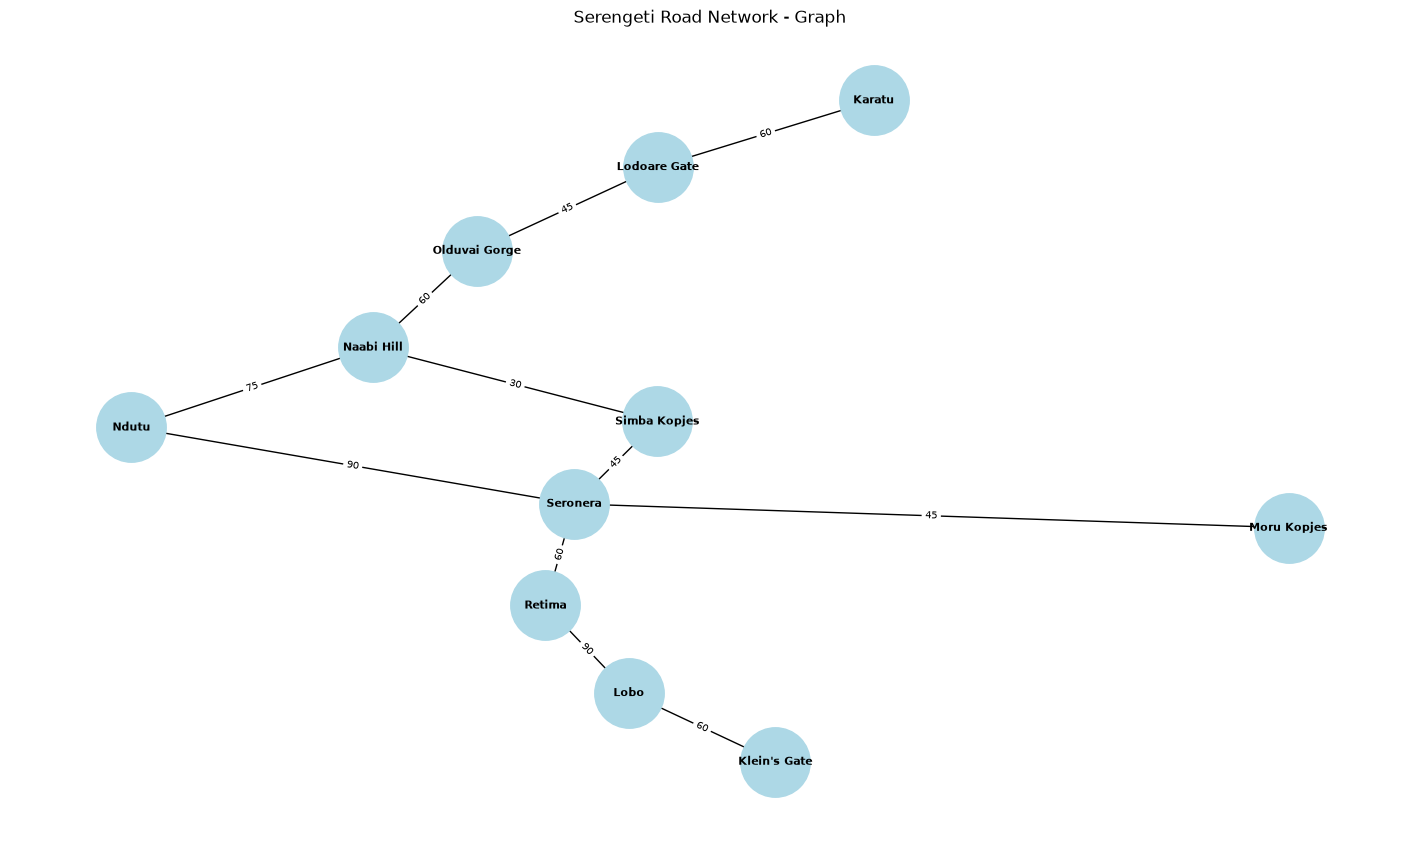

In [25]:
plt.figure(figsize=(14, 8))
nx.draw(G, pos,
        with_labels=True,
        node_color='lightblue',
        node_size=2500,
        font_size=8,
        font_weight='bold')
nx.draw_networkx_edge_labels(G, pos, edge_labels=edge_labels, font_size=7)
plt.title("Serengeti Road Network - Graph")
plt.tight_layout()
plt.show()